# Posterior Predictive Checks: Ordinal DCM (GWT)

**Purpose:** Simulate ratings from the fitted ordinal DCM and compare against what the experts actually gave. If the model is well-calibrated, the posterior predictive distribution of ratings should be consistent with the observed data. Clear misfit (e.g., an expert clustering at the extremes while the model predicts something unimodal) would motivate extensions like expert-specific cutpoints or per-expert discrimination.

**Approach:** For each posterior draw $\theta^{(s)} = (\kappa, \mathbf{b}, a, q_j)$ and each observation $(j, e, r_{\text{obs}})$:
$$P(r = k \mid \theta^{(s)}) = q_j^{(s)} \cdot P_{\text{OP}}(k \mid \kappa, b_e + a) + (1 - q_j^{(s)}) \cdot P_{\text{OP}}(k \mid \kappa, b_e)$$
where $P_{\text{OP}}$ is the ordered probit probability and $q_j$ is the prior probability of indicator presence from the tree (not the posterior $P(z_j=1 \mid \text{data})$, since we marginalise over $z_j$ in the generative model).

**Sections:**
1. Setup and model fit
2. Posterior predictive computation
3. Aggregate PPC (all observations pooled)
4. Per-expert calibration
5. Per-indicator diagnostics
6. Summary and implications

In [1]:
import sys, os, warnings, string

sys.path.insert(0, "..")
os.chdir(os.path.join(os.path.dirname(os.path.abspath("."))))
warnings.filterwarnings("ignore", message="Loop fusion failed")
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import arviz as az
import matplotlib.pyplot as plt
from scipy import stats

from dcm_model import (
    ModelConfig,
    OrdinalDataProcessor,
    EvidenceProcessor,
    BayesianModelBuilder,
    ResultsManager,
    load_data,
    node_key,
)

plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

---
## 1. Setup and model fit

In [2]:
config = ModelConfig(
    NUM_SAMPLES=1000,
    NUM_TUNE=1000,
    NUM_CHAINS=4,
    TARGET_ACCEPT=0.95,
)

all_data = load_data(config)
stance_data = next(s for s in all_data if s["name"] == config.TARGET_STANCE)

processor = OrdinalDataProcessor(config)
processor.process(stance_data, config.TARGET_SYSTEM)

anon_names = {
    name: f"Expert {letter}"
    for letter, name in zip(string.ascii_uppercase, processor.expert_names)
}

print(f"Experts: {list(anon_names.values())}")
print(f"Anchor expert: {anon_names[processor.anchor_expert]}")
print(f"Indicators with observations: {len(processor.observations)}")
print(f"Total ratings: {sum(len(v) for v in processor.observations.values())}")

Experts: ['Expert A', 'Expert B', 'Expert C', 'Expert D']
Anchor expert: Expert A
Indicators with observations: 50
Total ratings: 186


In [3]:
evidence_proc = EvidenceProcessor(config)
builder = BayesianModelBuilder(config, evidence_proc, processor)
model = builder.build_model(stance_data)
idata = builder.sample(model)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [global_workspace_theory_beta, a, b_free, kappa, representationality_beta_pres, representationality_beta_abs, conceptual_representations_beta_pres, conceptual_representations_beta_abs, activation_steering_effects_beta_pres, activation_steering_effects_beta_abs, probe-detectable_themes_beta_pres, probe-detectable_themes_beta_abs, concept-specific_ablation_effects_beta_pres, concept-specific_ablation_effects_beta_abs, propositional_representations_beta_pres, propositional_representations_beta_abs, logical_inference_beta_pres, logical_inference_beta_abs, world_modelling_beta_pres, world_modelling_beta_abs, model_isomorphism_beta_pres, model_isomorphism_beta_abs, broad_predictive_training_beta_pres, broad_predictive_training_beta_abs, isomorphic_representations_beta_pres, isomorphic_representations_beta_abs, somatotopic_neural_maps_beta_pres, somatotopic_neural_maps_beta_abs, has_retinotopic_neura

/Users/ryankelly/ryan-code/research/dcm-code/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 102 seconds.


---
## 2. Posterior predictive computation

For each observation $(j, e, r_{\text{obs}})$ and each posterior draw, compute the full predictive distribution over 7 rating categories. This marginalises $z_j$ using $q_j$ (the tree-implied prior, not the data-updated $P(z_j=1)$).

In [4]:
def ordered_probit_probs(kappa: np.ndarray, eta: np.ndarray, K: int = 7) -> np.ndarray:
    """Compute category probabilities under the ordered probit model.

    Parameters
    ----------
    kappa : (..., K-1) cutpoints
    eta : (...,) linear predictor (broadcast-compatible with kappa[..., 0])
    K : number of categories

    Returns
    -------
    (..., K) array of category probabilities.
    """
    # Phi(kappa - eta) for each cutpoint
    cum = stats.norm.cdf(kappa - eta[..., None])  # (..., K-1)
    zeros = np.zeros(cum.shape[:-1] + (1,))
    ones = np.ones(cum.shape[:-1] + (1,))
    cum_full = np.concatenate([zeros, cum, ones], axis=-1)  # (..., K+1)
    probs = np.diff(cum_full, axis=-1)  # (..., K)
    return np.clip(probs, 1e-12, 1.0)


def compute_ppc(
    idata,
    builder: BayesianModelBuilder,
    processor: OrdinalDataProcessor,
    K: int = 7,
    thin: int = 1,
) -> dict:
    """Compute posterior predictive rating distributions for all observations.

    Returns
    -------
    dict with keys:
      'obs_ratings' : (N,) observed ratings
      'obs_experts' : (N,) expert indices
      'obs_keys'    : (N,) indicator node keys
      'pred_probs'  : (N, K) mean posterior predictive P(rating=k) per observation
      'pred_samples': (N, S) sampled ratings from the posterior predictive
    """
    post = idata.posterior

    # Extract posterior draws: flatten (chain, draw) -> (S,)
    kappa_draws = post["kappa"].values.reshape(-1, K - 1)[::thin]  # (S, K-1)
    a_draws = post["a"].values.flatten()[::thin]  # (S,)
    n_experts = len(processor.expert_names)
    if n_experts > 1:
        b_free = post["b_free"].values.reshape(-1, n_experts - 1)[::thin]  # (S, E-1)
        b_draws = np.concatenate(
            [np.zeros((b_free.shape[0], 1)), b_free], axis=1
        )  # (S, E)
    else:
        b_draws = np.zeros((kappa_draws.shape[0], 1))
    S = kappa_draws.shape[0]

    # Collect all observations and their q_j draws
    obs_ratings, obs_experts, obs_keys = [], [], []
    qj_draws_list = []  # each entry: (S,) array of q_j posterior draws

    for nkey, obs_list in processor.observations.items():
        varname = builder.node_to_varname.get(nkey)
        if varname is None:
            continue
        # q_j = P(indicator present | tree) -- this is the _p deterministic
        p_name = f"{varname}_p"
        if p_name not in post:
            continue
        qj = post[p_name].values.flatten()[::thin]  # (S,)

        for expert_idx, rating in obs_list:
            obs_ratings.append(rating)
            obs_experts.append(expert_idx)
            obs_keys.append(nkey)
            qj_draws_list.append(qj)

    N = len(obs_ratings)
    obs_ratings = np.array(obs_ratings, dtype=int)
    obs_experts = np.array(obs_experts, dtype=int)
    qj_draws = np.stack(qj_draws_list)  # (N, S)

    # Vectorised PPC: for each observation i and draw s
    # eta_z0[i, s] = b[expert_i, s]
    # eta_z1[i, s] = b[expert_i, s] + a[s]
    eta_z0 = b_draws[:, obs_experts].T  # (N, S)
    eta_z1 = eta_z0 + a_draws[None, :]  # (N, S)

    # P(rating=k | z=0) and P(rating=k | z=1) for each (i, s)
    # kappa_draws is (S, K-1); eta_z0 is (N, S)
    # We need (N, S, K) -- compute in chunks to avoid huge memory
    pred_probs = np.zeros((N, K))  # mean over draws
    rng = np.random.default_rng(42)
    pred_samples = np.zeros((N, S), dtype=int)

    chunk_size = 50  # process observations in chunks
    for start in range(0, N, chunk_size):
        end = min(start + chunk_size, N)
        n_chunk = end - start

        # (n_chunk, S, K-1) cutpoints broadcast
        kappa_bc = np.broadcast_to(kappa_draws[None, :, :], (n_chunk, S, K - 1))

        probs_z0 = ordered_probit_probs(kappa_bc, eta_z0[start:end])  # (n_chunk, S, K)
        probs_z1 = ordered_probit_probs(kappa_bc, eta_z1[start:end])  # (n_chunk, S, K)

        qj_chunk = qj_draws[start:end, :, None]  # (n_chunk, S, 1)
        mixed = qj_chunk * probs_z1 + (1 - qj_chunk) * probs_z0  # (n_chunk, S, K)

        pred_probs[start:end] = mixed.mean(axis=1)  # (n_chunk, K)

        # Sample from predictive: for each (i, s), sample one rating
        for i_local in range(n_chunk):
            for s in range(S):
                pred_samples[start + i_local, s] = rng.choice(K, p=mixed[i_local, s])

    return {
        "obs_ratings": obs_ratings,
        "obs_experts": obs_experts,
        "obs_keys": np.array(obs_keys),
        "pred_probs": pred_probs,
        "pred_samples": pred_samples,
    }

In [5]:
ppc = compute_ppc(idata, builder, processor, thin=2)
print(f"Observations: {len(ppc['obs_ratings'])}")
print(f"Posterior draws used: {ppc['pred_samples'].shape[1]}")

Observations: 186
Posterior draws used: 2000


---
## 3. Aggregate PPC: observed vs predicted rating distributions

Pool all observations and compare the observed histogram of ratings against the posterior predictive distribution. If the model is well-calibrated, the two should align closely.

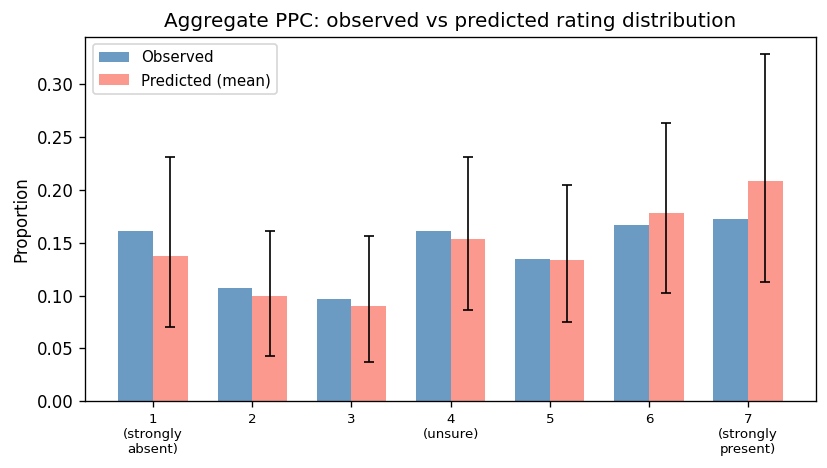

Category       Observed  Predicted           94% CI
--------------------------------------------------
  1               0.161      0.138 [0.070, 0.231]
  2               0.108      0.100 [0.043, 0.161]
  3               0.097      0.090 [0.038, 0.156]
  4               0.161      0.153 [0.086, 0.231]
  5               0.134      0.133 [0.075, 0.204]
  6               0.167      0.178 [0.102, 0.263]
  7               0.172      0.208 [0.113, 0.328]


In [6]:
K = 7
obs = ppc["obs_ratings"]
pred = ppc["pred_samples"]

# Observed histogram
obs_counts = np.bincount(obs, minlength=K) / len(obs)

# Posterior predictive: mean and 94% interval of the histogram
S = pred.shape[1]
pred_hists = np.zeros((S, K))
for s in range(S):
    pred_hists[s] = np.bincount(pred[:, s], minlength=K) / len(obs)

pred_mean = pred_hists.mean(axis=0)
pred_lo = np.percentile(pred_hists, 3, axis=0)
pred_hi = np.percentile(pred_hists, 97, axis=0)

labels = [
    "1\n(strongly\nabsent)",
    "2",
    "3",
    "4\n(unsure)",
    "5",
    "6",
    "7\n(strongly\npresent)",
]
cats = np.arange(K)
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(
    cats - width / 2, obs_counts, width, label="Observed", color="steelblue", alpha=0.8
)
ax.bar(
    cats + width / 2,
    pred_mean,
    width,
    label="Predicted (mean)",
    color="salmon",
    alpha=0.8,
)
ax.errorbar(
    cats + width / 2,
    pred_mean,
    yerr=[pred_mean - pred_lo, pred_hi - pred_mean],
    fmt="none",
    color="black",
    capsize=3,
    linewidth=1,
)
ax.set_xticks(cats)
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("Proportion")
ax.set_title("Aggregate PPC: observed vs predicted rating distribution")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

# Numeric summary
print(f"{'Category':<12} {'Observed':>10} {'Predicted':>10} {'94% CI':>16}")
print("-" * 50)
for k in range(K):
    print(
        f"  {k + 1:<10} {obs_counts[k]:>10.3f} {pred_mean[k]:>10.3f} [{pred_lo[k]:.3f}, {pred_hi[k]:.3f}]"
    )

### Bayesian p-values

For a scalar summary statistic $T(y)$, the Bayesian p-value is $P(T(y^{\text{rep}}) \geq T(y^{\text{obs}}))$. Values near 0 or 1 indicate misfit. We check the mean, variance, and proportion of extreme ratings (1 or 7).

Bayesian p-values (values near 0 or 1 indicate misfit):
  Mean rating:           obs=3.19, p=0.756
  Variance:              obs=4.29, p=0.365
  Proportion extreme:    obs=0.33, p=0.589


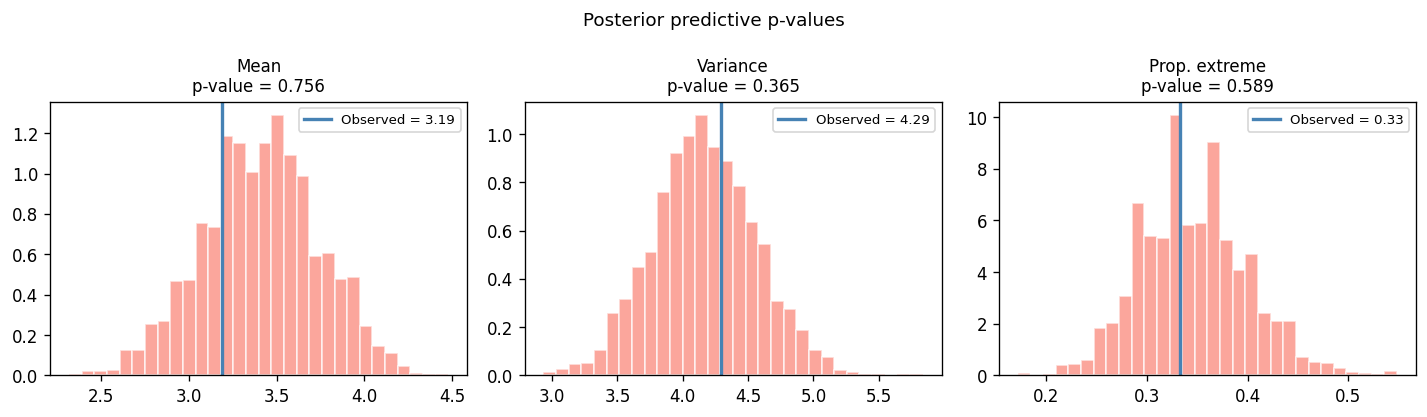

In [7]:
def bayesian_pvalue(obs_stat: float, pred_stats: np.ndarray) -> float:
    return float(np.mean(pred_stats >= obs_stat))


# Test statistics
obs_mean = obs.mean()
obs_var = obs.var()
obs_extreme = np.mean((obs == 0) | (obs == 6))

pred_means = pred.mean(axis=0)  # (S,)
pred_vars = pred.var(axis=0)
pred_extremes = np.mean((pred == 0) | (pred == 6), axis=0)

print("Bayesian p-values (values near 0 or 1 indicate misfit):")
print(
    f"  Mean rating:           obs={obs_mean:.2f}, p={bayesian_pvalue(obs_mean, pred_means):.3f}"
)
print(
    f"  Variance:              obs={obs_var:.2f}, p={bayesian_pvalue(obs_var, pred_vars):.3f}"
)
print(
    f"  Proportion extreme:    obs={obs_extreme:.2f}, p={bayesian_pvalue(obs_extreme, pred_extremes):.3f}"
)

# Scatter: observed vs replicated test statistic
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, (name, obs_stat, pred_stat) in zip(
    axes,
    [
        ("Mean", obs_mean, pred_means),
        ("Variance", obs_var, pred_vars),
        ("Prop. extreme", obs_extreme, pred_extremes),
    ],
):
    ax.hist(
        pred_stat, bins=30, density=True, color="salmon", alpha=0.7, edgecolor="white"
    )
    ax.axvline(
        obs_stat, color="steelblue", linewidth=2, label=f"Observed = {obs_stat:.2f}"
    )
    pval = bayesian_pvalue(obs_stat, pred_stat)
    ax.set_title(f"{name}\np-value = {pval:.3f}", fontsize=10)
    ax.legend(fontsize=8)

fig.suptitle("Posterior predictive p-values", fontsize=11)
fig.tight_layout()
plt.show()

---
## 4. Per-expert calibration

Does any expert's rating pattern deviate from what the model predicts for them? We compare each expert's observed rating distribution against their posterior predictive distribution.

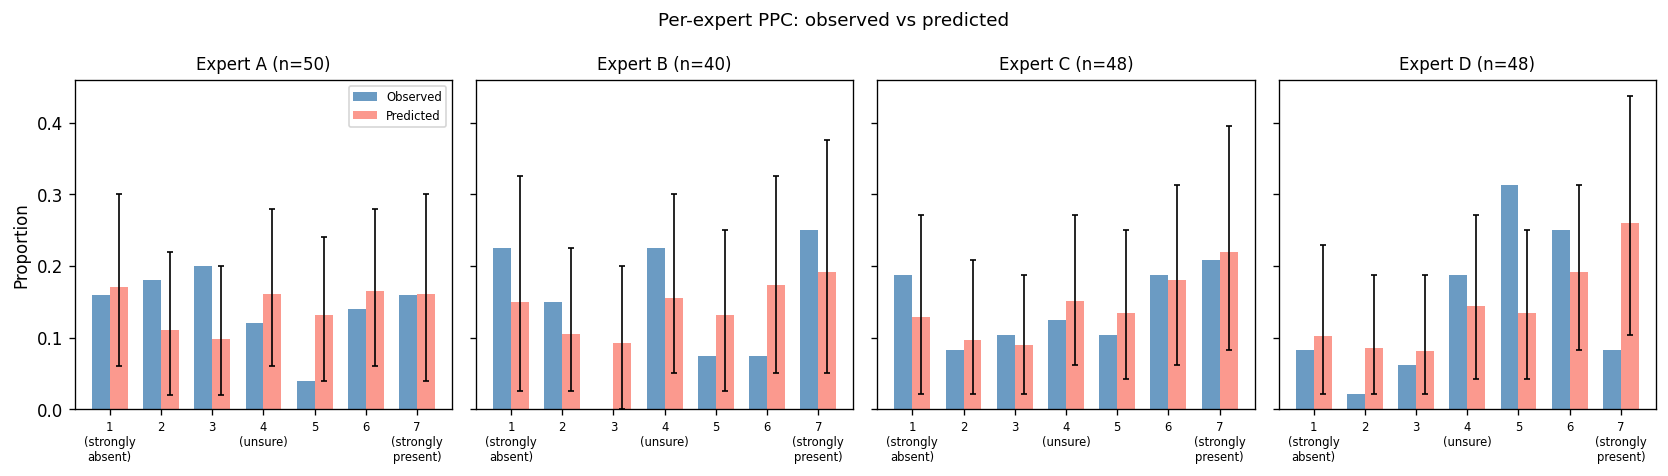

Expert         n  Obs mean  p(mean)   Obs var   p(var)
-------------------------------------------------------
Expert A      50      2.76    0.792     4.34    0.361
Expert B      40      3.00    0.733     5.25    0.036 *
Expert C      48      3.27    0.681     4.78    0.120
Expert D      48      3.71    0.553     2.46    0.977 *


In [8]:
n_experts = len(processor.expert_names)
fig, axes = plt.subplots(1, n_experts, figsize=(3.5 * n_experts, 4), sharey=True)
if n_experts == 1:
    axes = [axes]

expert_pvals = {}  # expert_idx -> dict of p-values

for eidx, ax in enumerate(axes):
    mask = ppc["obs_experts"] == eidx
    if mask.sum() == 0:
        continue

    e_obs = ppc["obs_ratings"][mask]
    e_pred = ppc["pred_samples"][mask]  # (n_e, S)
    n_e = len(e_obs)

    e_obs_counts = np.bincount(e_obs, minlength=K) / n_e
    e_pred_hists = np.zeros((S, K))
    for s in range(S):
        e_pred_hists[s] = np.bincount(e_pred[:, s], minlength=K) / n_e
    e_pred_mean = e_pred_hists.mean(axis=0)
    e_pred_lo = np.percentile(e_pred_hists, 3, axis=0)
    e_pred_hi = np.percentile(e_pred_hists, 97, axis=0)

    ax.bar(
        cats - width / 2,
        e_obs_counts,
        width,
        color="steelblue",
        alpha=0.8,
        label="Observed",
    )
    ax.bar(
        cats + width / 2,
        e_pred_mean,
        width,
        color="salmon",
        alpha=0.8,
        label="Predicted",
    )
    ax.errorbar(
        cats + width / 2,
        e_pred_mean,
        yerr=[e_pred_mean - e_pred_lo, e_pred_hi - e_pred_mean],
        fmt="none",
        color="black",
        capsize=2,
        linewidth=1,
    )
    ax.set_xticks(cats)
    ax.set_xticklabels(labels, fontsize=7)

    name = processor.expert_names[eidx]
    ax.set_title(f"{anon_names[name]} (n={n_e})", fontsize=10)
    if eidx == 0:
        ax.set_ylabel("Proportion")
        ax.legend(fontsize=7)

    # Per-expert p-values
    e_obs_mean = e_obs.mean()
    e_obs_var = e_obs.var()
    e_pred_means_s = e_pred.mean(axis=0)
    e_pred_vars_s = e_pred.var(axis=0)
    expert_pvals[eidx] = {
        "name": anon_names[name],
        "n": n_e,
        "obs_mean": e_obs_mean,
        "p_mean": bayesian_pvalue(e_obs_mean, e_pred_means_s),
        "obs_var": e_obs_var,
        "p_var": bayesian_pvalue(e_obs_var, e_pred_vars_s),
    }

fig.suptitle("Per-expert PPC: observed vs predicted", fontsize=11)
fig.tight_layout()
plt.show()

# Summary table
print(
    f"{'Expert':<12} {'n':>3} {'Obs mean':>9} {'p(mean)':>8} {'Obs var':>9} {'p(var)':>8}"
)
print("-" * 55)
for eidx in sorted(expert_pvals):
    ep = expert_pvals[eidx]
    flag_m = " *" if ep["p_mean"] < 0.05 or ep["p_mean"] > 0.95 else ""
    flag_v = " *" if ep["p_var"] < 0.05 or ep["p_var"] > 0.95 else ""
    print(
        f"{ep['name']:<12} {ep['n']:>3} "
        f"{ep['obs_mean']:>9.2f} {ep['p_mean']:>8.3f}{flag_m}"
        f"{ep['obs_var']:>9.2f} {ep['p_var']:>8.3f}{flag_v}"
    )

---
## 5. Per-indicator diagnostics

For each indicator, compute the log-predictive density of the observed ratings under the posterior predictive. Indicators with the lowest scores are the worst-fitting -- candidates for model extension.

In [9]:
# Per-observation log-predictive score: log P(r_obs | theta) averaged over draws
obs_r = ppc["obs_ratings"]
pred_p = ppc["pred_probs"]  # (N, K)
log_pred_scores = np.log(pred_p[np.arange(len(obs_r)), obs_r])  # (N,)

# Aggregate by indicator
indicator_scores = []
unique_keys = np.unique(ppc["obs_keys"])
for nkey in unique_keys:
    mask = ppc["obs_keys"] == nkey
    n_obs = mask.sum()
    mean_lps = log_pred_scores[mask].mean()
    obs_here = obs_r[mask]
    pred_here = pred_p[mask]  # (n_obs, K)

    parts = nkey.split(" > ")
    short_name = " > ".join(parts[-2:]) if len(parts) >= 2 else parts[-1]

    indicator_scores.append(
        {
            "key": nkey,
            "name": short_name,
            "n": n_obs,
            "mean_log_pred": mean_lps,
            "obs_ratings": obs_here,
            "pred_probs": pred_here,
        }
    )

indicator_scores.sort(key=lambda x: x["mean_log_pred"])

print(f"{'Indicator':<55} {'n':>3} {'Mean log-pred':>13}")
print("-" * 75)
for r in indicator_scores:
    flag = " <<" if r["mean_log_pred"] < -2.5 else ""
    print(f"{r['name'][:54]:<55} {r['n']:>3} {r['mean_log_pred']:>13.3f}{flag}")

Indicator                                                 n Mean log-pred
---------------------------------------------------------------------------
Capability Attention Modulation > Adaptive Learning       3        -2.673 <<
Modularity > Dedicated Sensory Systems                    4        -2.396
Isomorphic Representations > Has Retinotopic Neural Ma    4        -2.287
Modularity > Cross-Modal Learning Deficits                4        -2.249
Common Representational Scheme > Authoritative Represe    3        -2.206
Isomorphic Representations > Somatotopic Neural Maps      4        -2.188
Non-Linear Capabilities > Self-Sustained Activity         4        -2.175
Structural Complexity > Functional Specialization         4        -2.157
Social Coherence > Persistence Seeking                    4        -2.133
Non-Linear Capabilities > Threshold Activation            3        -2.124
World Modelling > Model Isomorphism                       3        -2.123
Performance Sensitivity > Couplin

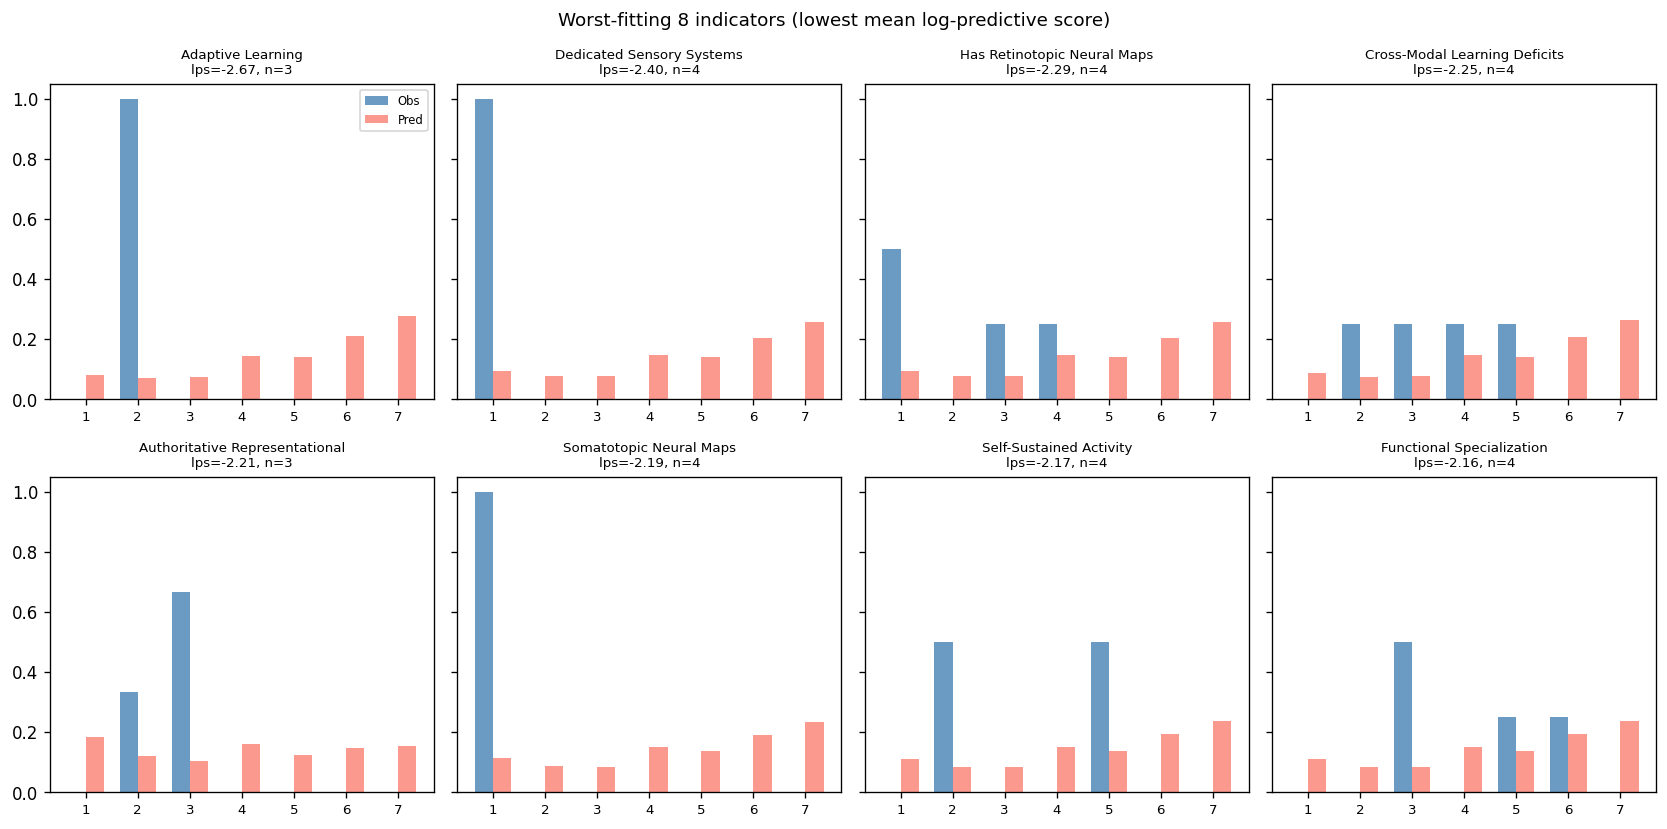

In [10]:
# Detailed view: worst-fitting indicators
n_worst = min(8, len(indicator_scores))
worst = indicator_scores[:n_worst]

n_cols = 4
n_rows = (n_worst + n_cols - 1) // n_cols
fig, axes = plt.subplots(
    n_rows, n_cols, figsize=(3.5 * n_cols, 3.5 * n_rows), sharey=True
)
axes_flat = axes.flatten() if n_worst > 1 else [axes]

for idx, (ax, ind) in enumerate(zip(axes_flat, worst)):
    n_obs = ind["n"]
    obs_hist = np.bincount(ind["obs_ratings"], minlength=K) / n_obs
    pred_hist = ind["pred_probs"].mean(axis=0)  # average predicted distribution

    ax.bar(cats - width / 2, obs_hist, width, color="steelblue", alpha=0.8, label="Obs")
    ax.bar(cats + width / 2, pred_hist, width, color="salmon", alpha=0.8, label="Pred")
    ax.set_xticks(cats)
    ax.set_xticklabels([str(k + 1) for k in cats], fontsize=8)
    title = ind["name"].split(" > ")[-1][:30]
    ax.set_title(f"{title}\nlps={ind['mean_log_pred']:.2f}, n={n_obs}", fontsize=8)
    if idx == 0:
        ax.legend(fontsize=7)

# Hide unused axes
for ax in axes_flat[n_worst:]:
    ax.set_visible(False)

fig.suptitle(
    f"Worst-fitting {n_worst} indicators (lowest mean log-predictive score)",
    fontsize=11,
)
fig.tight_layout()
plt.show()

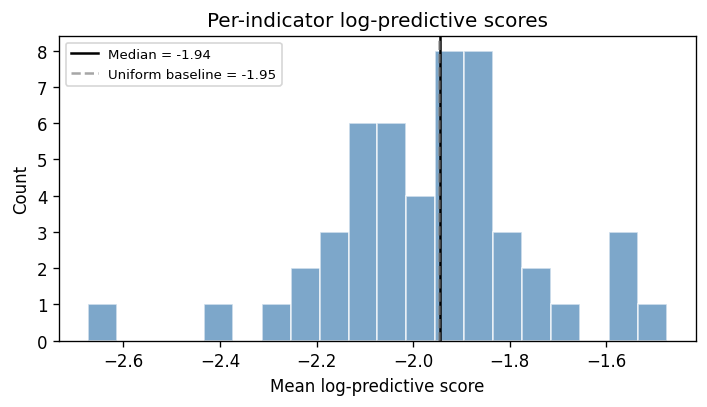

Indicators scoring worse than uniform: 25/50


In [11]:
# Distribution of log-predictive scores across all indicators
all_lps = [r["mean_log_pred"] for r in indicator_scores]

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(all_lps, bins=20, color="steelblue", alpha=0.7, edgecolor="white")
ax.axvline(
    np.median(all_lps),
    color="black",
    linestyle="-",
    label=f"Median = {np.median(all_lps):.2f}",
)
ax.axvline(
    -np.log(K),
    color="grey",
    linestyle="--",
    alpha=0.7,
    label=f"Uniform baseline = {-np.log(K):.2f}",
)
ax.set_xlabel("Mean log-predictive score")
ax.set_ylabel("Count")
ax.set_title("Per-indicator log-predictive scores")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

n_below_uniform = sum(1 for lps in all_lps if lps < -np.log(K))
print(f"Indicators scoring worse than uniform: {n_below_uniform}/{len(all_lps)}")

### Expert disagreement on worst-fitting indicators

For the worst-fitting indicators, is the misfit driven by expert disagreement (bimodal observed ratings) or by a systematic shift from model predictions?

In [12]:
# For worst indicators, show per-expert ratings
n_show = min(6, len(worst))

for ind in worst[:n_show]:
    nkey = ind["key"]
    mask = ppc["obs_keys"] == nkey
    experts_here = ppc["obs_experts"][mask]
    ratings_here = ppc["obs_ratings"][mask]

    parts = nkey.split(" > ")
    short = " > ".join(parts[-2:]) if len(parts) >= 2 else parts[-1]
    print(f"\n{short} (lps={ind['mean_log_pred']:.2f}):")
    for eidx, rating in zip(experts_here, ratings_here):
        ename = anon_names[processor.expert_names[eidx]]
        print(f"  {ename}: {rating + 1}")


Capability Attention Modulation > Adaptive Learning (lps=-2.67):
  Expert C: 2
  Expert A: 2
  Expert D: 2

Modularity > Dedicated Sensory Systems (lps=-2.40):
  Expert C: 1
  Expert B: 1
  Expert A: 1
  Expert D: 1

Isomorphic Representations > Has Retinotopic Neural Maps (lps=-2.29):
  Expert C: 1
  Expert B: 1
  Expert A: 3
  Expert D: 4

Modularity > Cross-Modal Learning Deficits (lps=-2.25):
  Expert C: 5
  Expert B: 4
  Expert A: 2
  Expert D: 3

Common Representational Scheme > Authoritative Representational Scheme (lps=-2.21):
  Expert C: 2
  Expert A: 3
  Expert D: 3

Isomorphic Representations > Somatotopic Neural Maps (lps=-2.19):
  Expert C: 1
  Expert B: 1
  Expert A: 1
  Expert D: 1


---
## 6. PPC conditioned on posterior $P(z_j = 1 \mid \text{data})$

The above PPC marginalises over $z_j$ using the tree prior $q_j$. We can also condition on the posterior $P(z_j = 1 \mid \text{data})$, which asks: "given what we infer about each indicator's state, do the predicted ratings match?" This isolates observation-model misfit from tree-prior misfit.

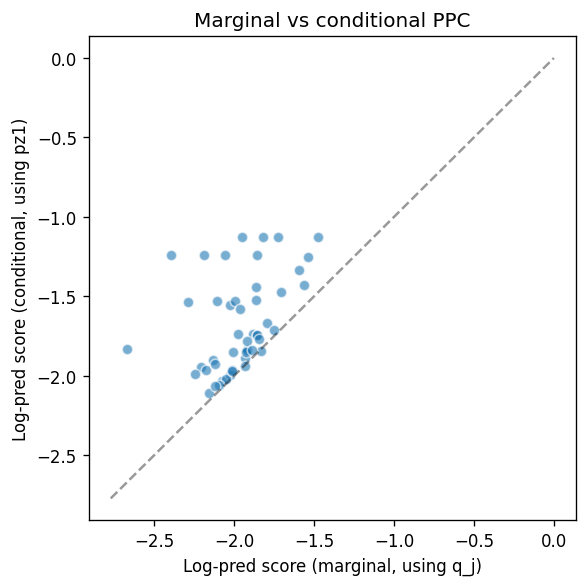

Indicators where conditioning on pz1 improves fit most (tree prior mismatch):
Indicator                                                Marginal     Cond.    Diff
-------------------------------------------------------------------------------------
Modularity > Dedicated Sensory Systems                     -2.396    -1.238  +1.157
Isomorphic Representations > Somatotopic Neural Maps       -2.188    -1.238  +0.950
Capability Attention Modulation > Adaptive Learning        -2.673    -1.832  +0.842
Modularity > Dedicated Speech Systems                      -1.954    -1.125  +0.829
Modularity > Dedicated Action Systems                      -2.061    -1.238  +0.823
Isomorphic Representations > Has Retinotopic Neural Ma     -2.287    -1.535  +0.752
Structural Complexity > Number of Layers                   -1.820    -1.125  +0.695
Informational Complexity > Optimized Componentry           -1.860    -1.238  +0.622
Conceptual Representations > Probe-Detectable Themes       -1.725    -1.125  +0.

In [13]:
def compute_ppc_conditional(
    idata,
    builder,
    processor,
    K=7,
    thin=1,
) -> dict:
    """PPC using posterior pz1 instead of prior q_j."""
    post = idata.posterior
    kappa_draws = post["kappa"].values.reshape(-1, K - 1)[::thin]
    a_draws = post["a"].values.flatten()[::thin]
    n_experts = len(processor.expert_names)
    if n_experts > 1:
        b_free = post["b_free"].values.reshape(-1, n_experts - 1)[::thin]
        b_draws = np.concatenate([np.zeros((b_free.shape[0], 1)), b_free], axis=1)
    else:
        b_draws = np.zeros((kappa_draws.shape[0], 1))
    S = kappa_draws.shape[0]

    obs_ratings, obs_experts, obs_keys = [], [], []
    pz1_draws_list = []

    for nkey, obs_list in processor.observations.items():
        varname = builder.node_to_varname.get(nkey)
        if varname is None:
            continue
        pz1_name = f"{varname}_pz1"
        if pz1_name not in post:
            continue
        pz1 = post[pz1_name].values.flatten()[::thin]
        for expert_idx, rating in obs_list:
            obs_ratings.append(rating)
            obs_experts.append(expert_idx)
            obs_keys.append(nkey)
            pz1_draws_list.append(pz1)

    N = len(obs_ratings)
    obs_ratings = np.array(obs_ratings, dtype=int)
    obs_experts = np.array(obs_experts, dtype=int)
    pz1_draws = np.stack(pz1_draws_list)  # (N, S)

    eta_z0 = b_draws[:, obs_experts].T
    eta_z1 = eta_z0 + a_draws[None, :]

    pred_probs = np.zeros((N, K))
    chunk_size = 50
    for start in range(0, N, chunk_size):
        end = min(start + chunk_size, N)
        n_chunk = end - start
        kappa_bc = np.broadcast_to(kappa_draws[None, :, :], (n_chunk, S, K - 1))
        probs_z0 = ordered_probit_probs(kappa_bc, eta_z0[start:end])
        probs_z1 = ordered_probit_probs(kappa_bc, eta_z1[start:end])
        pz1_chunk = pz1_draws[start:end, :, None]
        mixed = pz1_chunk * probs_z1 + (1 - pz1_chunk) * probs_z0
        pred_probs[start:end] = mixed.mean(axis=1)

    log_pred = np.log(pred_probs[np.arange(N), obs_ratings])

    return {
        "obs_ratings": obs_ratings,
        "obs_keys": np.array(obs_keys),
        "pred_probs": pred_probs,
        "log_pred": log_pred,
    }


ppc_cond = compute_ppc_conditional(idata, builder, processor, thin=2)

# Compare marginal vs conditional log-predictive scores
lps_marginal = []
lps_conditional = []
ind_names = []

for nkey in unique_keys:
    mask_m = ppc["obs_keys"] == nkey
    mask_c = ppc_cond["obs_keys"] == nkey
    if mask_m.sum() == 0 or mask_c.sum() == 0:
        continue
    lps_m = log_pred_scores[mask_m].mean()
    lps_c = ppc_cond["log_pred"][mask_c].mean()
    parts = nkey.split(" > ")
    short = " > ".join(parts[-2:]) if len(parts) >= 2 else parts[-1]
    lps_marginal.append(lps_m)
    lps_conditional.append(lps_c)
    ind_names.append(short)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(lps_marginal, lps_conditional, alpha=0.6, edgecolor="white", s=40)
lim = [min(min(lps_marginal), min(lps_conditional)) - 0.1, 0]
ax.plot(lim, lim, "k--", alpha=0.4)
ax.set_xlabel("Log-pred score (marginal, using q_j)")
ax.set_ylabel("Log-pred score (conditional, using pz1)")
ax.set_title("Marginal vs conditional PPC")
fig.tight_layout()
plt.show()

# Indicators where conditional is much better than marginal
# => tree prior is pulling q_j away from the data-supported z state
diffs = np.array(lps_conditional) - np.array(lps_marginal)
order = np.argsort(diffs)[::-1]
print("Indicators where conditioning on pz1 improves fit most (tree prior mismatch):")
print(f"{'Indicator':<55} {'Marginal':>9} {'Cond.':>9} {'Diff':>7}")
print("-" * 85)
for i in order[:10]:
    print(
        f"{ind_names[i][:54]:<55} {lps_marginal[i]:>9.3f} {lps_conditional[i]:>9.3f} {diffs[i]:>+7.3f}"
    )

---
## 7. Summary and implications

### Aggregate calibration is good

The overall predicted rating distribution closely matches the observed data. Bayesian p-values for the mean (0.76), variance (0.37), and proportion of extreme ratings (0.59) are all comfortably within the healthy range -- no systematic misfit at the aggregate level. The observation model (shared ordered probit with per-expert location shifts) is doing a reasonable job of capturing the global shape of expert responses.

### Per-expert: mild signal for expert-specific discrimination

Expert B gives more variable ratings than the model predicts (variance p-value = 0.04), while Expert D gives less variable ratings than predicted (p = 0.98). The location shift $b_e$ captures differences in mean leniency but cannot absorb differences in *decisiveness*. Per-expert discrimination $a_e$ would address this, but the signal is not dramatic -- this is a lower-priority extension.

Expert-specific cutpoints $\kappa_e$ are not clearly motivated: none of the per-expert distributions show qualitatively different shapes (e.g., bimodal vs unimodal).

### Per-indicator: half score worse than uniform, driven by tree priors

25 of 50 indicators have mean log-predictive scores below the uniform baseline ($\log(1/7) \approx -1.95$). The worst-fitting indicators (e.g., Adaptive Learning at $-2.67$, Dedicated Sensory Systems at $-2.40$) are cases where experts unanimously agree on low or absent ratings, but the support/demandingness-derived tree prior $q_j$ assigns non-trivial presence probability.

Critically, the **marginal vs conditional PPC comparison** (Section 6) isolates the source of misfit. Indicators like Dedicated Sensory Systems (+1.16 improvement when conditioning on $P(z_j=1 \mid \text{data})$), Somatotopic Neural Maps (+0.95), and Dedicated Speech Systems (+0.83) are dramatically better-predicted when using the posterior indicator state rather than the tree prior. This confirms that the observation model itself is well-specified -- the misfit comes from the tree prior layer (support/demandingness $\to$ Beta parameters) rather than how ratings are generated conditional on indicator state.

### What this motivates

1. **Support/demandingness is the priority.** The dominant source of predictive misfit is the tree prior, not the observation model. This aligns with the finding from notebook 06 that the model is prior-dominated (mean |shift| = 0.004 between prior and posterior Beta means). Reconceptualising or recalibrating the support/demandingness specification would have far more impact than observation-model extensions.

2. **Per-expert discrimination is a secondary extension.** The Expert B/D variance asymmetry is real but modest. Worth implementing if the model is being refined, but unlikely to change headline conclusions.

3. **Expert-specific cutpoints are not needed** at present -- the shared cutpoints with per-expert shifts adequately capture cross-expert variation in rating patterns.

4. **The observation model is working.** The ordered probit with marginalised $z_j$ is a sound foundation for extending to other stances (Task 6) without needing structural changes to the observation layer.